## Optimizer Visualizations
The following optimizers will be implemented and visualized below:
- Full Batch Gradient Descent
- Mini-batch SGD (Stochastic Gradient Descent)
- SGD + Momentum
- Adagrad
- RMSProp (Root Mean Square Propogation)
- Adam (Adaptive Moment Estimation)

In [32]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

X, y = make_moons(n_samples=500, noise=0.25)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)

In [33]:
class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 16)
        self.fc2 = nn.Linear(16, 16)
        self.fc3 = nn.Linear(16, 2)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

In [34]:
def train_optimizer(model, optimizer, epochs=100, batch_size=None, verbose=False):
    criterion = nn.CrossEntropyLoss()
    n = X_train.shape[0]
    losses = []

    for epoch in range(epochs):
        if batch_size is None:
            # Full batch
            X_batch, y_batch = X_train, y_train
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
        else:
            # Mini-batch
            perm = torch.randperm(n)
            for i in range(0, n, batch_size):
                idx = perm[i:i+batch_size]
                X_batch, y_batch = X_train[idx], y_train[idx]
                optimizer.zero_grad()
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                loss.backward()
                optimizer.step()

        # Record training loss
        with torch.no_grad():
            outputs = model(X_train)
            loss_val = criterion(outputs, y_train).item()
            losses.append(loss_val)

        if verbose:
            print(f"Epoch {epoch+1}, Loss: {loss_val}")

    return losses

In [35]:
model_gd = TinyNet()
optimizer_gd = torch.optim.SGD(model_gd.parameters(), lr=0.1)  # full batch

model_sgd = TinyNet()
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.1)

model_momentum = TinyNet()
optimizer_momentum = torch.optim.SGD(model_momentum.parameters(), lr=0.1, momentum=0.9)

model_adagrad = TinyNet()
optimizer_adagrad = torch.optim.Adagrad(model_adagrad.parameters(), lr=0.1)

model_rmsprop = TinyNet()
optimizer_rmsprop = torch.optim.RMSprop(model_rmsprop.parameters(), lr=0.01)

model_adam = TinyNet()
optimizer_adam = torch.optim.Adam(model_adam.parameters(), lr=0.01)

### Quick Note
Full Gradient Descent and SGD can be slow to converge and noisy, so commenting them out before plotting can help get a better look at the more efficient optimizers and their differences (SGD + Momentum, Adagrad, RMSProp, Adam).

You can also comment out Full Gradient Descent, SGD, and SGD + Momentum to  look at the more effective optimizers. RMSProp and Adam improve upon their parent, Adagrad, so comparing how much quicker they converge and how little they oscillate can be interesting to look at as well.

**Remember** to run code from top to bottom again when commenting out optimizers!

In [36]:
losses_dict = {}

losses_dict["Full GD"] = train_optimizer(model_gd, optimizer_gd, epochs=100, batch_size=None)
losses_dict["SGD"] = train_optimizer(model_sgd, optimizer_sgd, epochs=100, batch_size=32)
losses_dict["SGD + Momentum"] = train_optimizer(model_momentum, optimizer_momentum, epochs=100, batch_size=32)
losses_dict["Adagrad"] = train_optimizer(model_adagrad, optimizer_adagrad, epochs=100, batch_size=32)
losses_dict["RMSProp"] = train_optimizer(model_rmsprop, optimizer_rmsprop, epochs=100, batch_size=32)
losses_dict["Adam"] = train_optimizer(model_adam, optimizer_adam, epochs=100, batch_size=32)

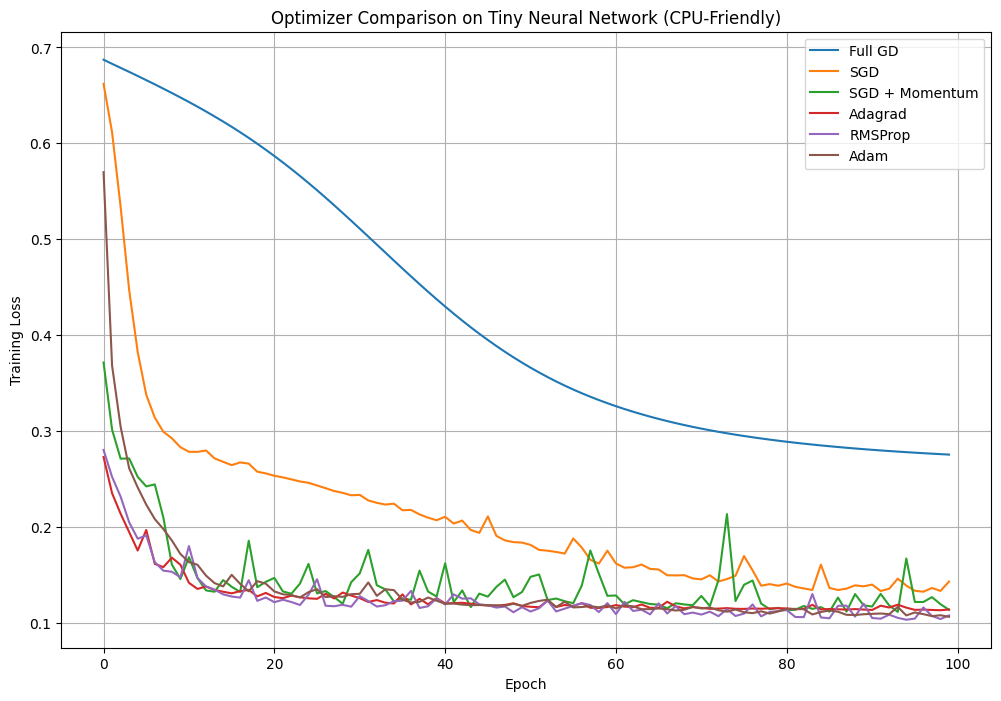

In [37]:
plt.figure(figsize=(12, 8))
for name, loss_vals in losses_dict.items():
    plt.plot(loss_vals, label=name)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Optimizer Comparison on Tiny Neural Network (CPU-Friendly)")
plt.legend()
plt.grid(True)
plt.show()

### Breaking Down Optimizers (Functionality, Pseudo-code, pros-cons)
**Full Batch Gradient Descent (GD)**: works by updating model parameters (weights and bias) in the directon of the negative gradient to reduce loss.
- "Full Batch" signifies that the gradient will be computed using the **entire** testing dataset at every step.
- **Good**: able to retrieve the exact gradients for the current dataset and smooth convergence.
- **Bad**: slow and computationally heavy on large datasets, runs into issues with local minima.

Stepthrough:
1. Compute gradients of loss data
2. Update parameters in the negative gradient direction

Pseudo-code:
```python
for epoch in range(epochs):
    grad = compute_gradients(loss, all_data)
    theta = theta - lr * grad
```

**Mini-Batch Stochastic Gradient Descent (SGD)**: improves of batch GD by only taking a single training example, or a small subset, in each epoch instead of the full dataset.
- Introduces noise to help escape shallow minima problem (also becomes a problem for this optimizer).
- **Good**: faster than GD, better convergence, less computationally heavy.
- **Bad**: noise introduces a less smooth loss curve, choice of batch size affects stability.

Stepthrough:
1. Randomly sample batch
2. Compute Gradients on batch
3. Update parameters

Pseudo-code:
```python
for epoch in range(epochs):
    for batch in data_loader:
        grad = compute_gradient(loss, batch)
        theta = theta - lr * grad
```

I**SGD + Momentum**: loss function landscape can be non-convex. Without momentum, SGD can get stuck in the local minima or spend too much time oscillating. Momentum helps smooth osciallations and keeps gradients moving towards global minimum.
- Momentum works by adding a fraction of the previous update to the current one.
- **Good**: faster convergence, reduces oscillations, helps escape local minima
- **Bad**: can overshoot minima, more memory required, and less adaptive as momentum does not adjust per parameter.

```python
v = 0
for epoch in range(epochs):
    for batch in data_loader:
        g = compute_gradient(loss, batch)
        v = beta * v + (1 - beta) * g
        theta = theta - lr * v
```

**Adagrad**: method that adjusts the learning rate for each parameter during testing. Unlike GD with a fixed rate, Adagrad uses past gradients to scale updates. Primary idea is to adapt the learning rate based on the historical sum of squared gradients for each parameters.
- **Good**: useful on sparse data, adjusting learning rate per parameter.
- **Bad**: Learning rate continously shrinks - not ideal for long training.

Stepthrough:
1. Initialize parameter values randomly (running sum of squared gradients for each parameter).
2. For each training step, the gradient of the loss function is calculated relative to the model weights.
3. Adagrad now adjusts learning rate for each parameter based on the accumulated sum of squared gradients.
4. Model parameters are updated.

Pseudo-code:
```python
G = 0
for epoch in range(epochs):
    for batch in data_loader:
        g = compute_gradient(loss, batch)
        G += g**2
        theta = theta - lr / (sqrt(G) + eps) * g
```

**Root Mean Square Propogation (RMSProp)**: addresses diminishing learning rate issue observed in Adagrad by introducing an exponentially decaying avergae of the squared gradients **instead** of accumulating the sum.
- **Good**:
- Prevents learning rate from decaying too quickly
- More effective at training deep neural networks --> can train for much longer than with Adagrad.
- **Bad**: Sensitivity to hyperparameters

Pseudo-code:
```python
v = 0
for epoch in range(epochs):
    for batch in data_loader:
        g = compute_gradient(loss, batch)
        v = beta * v + (1 - beta) * g**2
        theta = theta - lr / (sqrt(v) + eps) * g
```

**Adaptive Moment Estimation (Adam)**: combines the benefits of both Adagrad and momentum-based methods.
- Uses both the moving average of the gradients and the squared gradients to adapt learning rate.
- Maintains first moment (mean) and second moment (variance) estimates.
- **Good**: Fast and smooth convergence, universal application.
- **Bad**: Adds additional hyperparameters, sometimes prone to overfitting with high learning rates.

Pseudo-code:
```python
m = 0
v = 0
t = 0
for epoch in range(epochs):
    for batch in data_loader:
        t += 1
        g = compute_gradient(loss, batch)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        theta = theta - lr * m_hat / (sqrt(v_hat) + eps)
```